# Cellphone Price Range Prediction using Machine Learning

This project focuses on **predicting the price range** of a mobile phone based on its technical specifications using Machine Learning techniques.


## Problem Statement

In today’s competitive mobile phone market, correct pricing of a mobile device is a critical business decision.
Bob, who has started his own mobile manufacturing company, wants to compete with major brands such as Apple and Samsung. However, he does not know how to determine the appropriate price range for the mobile phones his company produces.

The price of a mobile phone depends on several technical specifications such as battery power, RAM, internal memory, camera quality, connectivity features (3G, 4G, WiFi), and processor performance.

In this project, we are **not predicting the exact price**, but instead predicting a **price range**:

- 0 - Low Cost

- 1 - Medium Cost

- 2 - High Cost

- 3 - Very High Cost

This is a **multiclass classification problem**.



#### Project Aim and Objectives

The main aim of this project is to build a machine learning model that accurately predicts the price range of a mobile phone based on its specifications.

The objective of this project is to:

    
- To Analyze mobile phone specifications
- To build multiple Machine Learning classification models
- To compare models and select the best performing model
- Understand the relationship between mobile features and price


## Dataset Description

- The Dataset contains mobile phone specifications like battery power, clock_speed, internal memory, camera quality, connectivity features etc..
- Number of records in the dataset: 2000
- Number of column or features  in the dataset: 21 (20 input features + 1 target)
- Target variable: **price_range**

Target Classes :

   - 0 → Low cost
   - 1 → Medium cost
   - 2 → High cost
   - 3 → Very high cost



## Import Required Libraries

In [4]:

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save model
import pickle

import warnings
warnings.filterwarnings('ignore')

**Insight:**

- These libraries help in data handling, visualization, model building, evaluation, and saving models.

## Load the Dataset

The dataset is loaded using Pandas and the first few rows are displayed to understand the structure of the data.

In [5]:
df = pd.read_csv("datasets_11167_15520_train.csv")
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


**Insight:**

- The dataset contains mobile phone specifications and a target variable called price_range.

#### Domain Analysis

- Higher RAM generally increases mobile price
- Better battery improves customer satisfaction
- Camera quality affects market demand
- Network features (3G/4G/WiFi) increase value


## Basic Dataset Information

In [6]:
# Display the first 5 rows
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [7]:
# Display the last 5 rows
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [8]:
df.shape

(2000, 21)

**Insight:**
- The dataset in 2000 records
- 20 input features of dataset
- 1 target variable

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [10]:
# Statistical Summary
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


**Statistical Summary**

The statistical summary provides insights into:

- RAM varies widely → strong impact on price
- Feature distributions
- Minimum and maximum values
- Mean and standard deviation
- Battery power and pixel resolution also show high variation

## Data Cleaning

In [11]:
# Check for missing values
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [12]:
# checks for Duplicate Records
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

In [13]:
# Target Variable Distribution
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

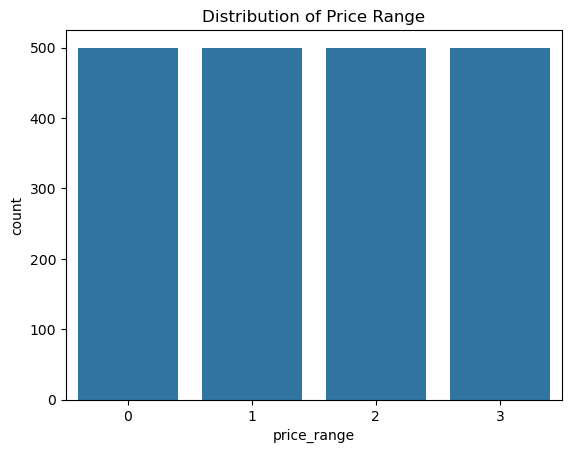

In [14]:
# Target Variable Distribution
sns.countplot(x='price_range', data=df)
plt.title("Distribution of Price Range")
plt.show()

**Insight:**

- Dataset is perfectly balanced
- No need for resampling techniques

### Correlation Analysis

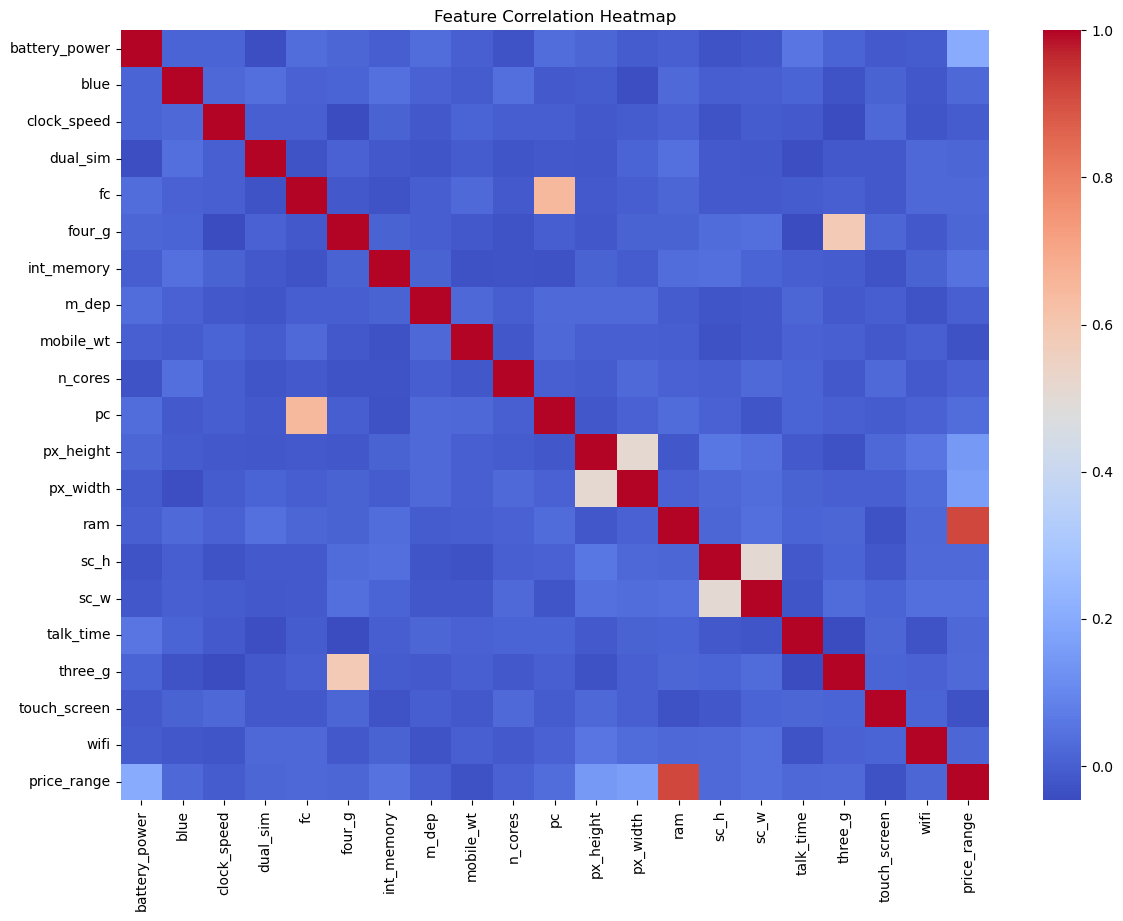

In [15]:
# Correlation Heatmap (EDA)
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

**Insights:**

- RAM has the highest correlation with price range
- Battery power, pixel resolution, and internal memory also impact price
- Connectivity features (4G, WiFi) add value but less impact than RAM

#### Relationship Between RAM and Price Range

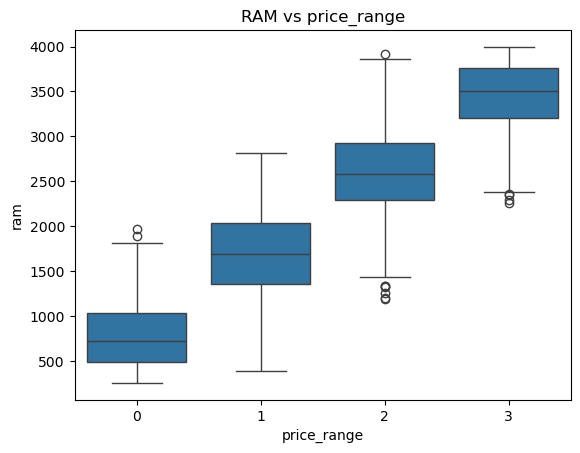

In [16]:
sns.boxplot(x='price_range', y='ram', data=df)
plt.title("RAM vs price_range")
plt.show()

**Important Feature Analysis**
- As RAM increases, the price range also increases.
- RAM is one of the strongest indicators of phone price.

## Feature Engineering

### Features & Target Separation

In [17]:
X = df.drop('price_range', axis=1)
y = df['price_range']

**Insight:**

The dataset is divided into:
- Independent variables (features,(X))
- Dependent variable (price_range,(Y))

### Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Insight:**

The dataset is split into:

- 80% training data
- 20% testing data
- Stratify ensures all price ranges are equally represented.

### Feature Scaling

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Insight:**
Standardization is applied to features because:

- Algorithms like KNN and SVM are distance-based
- Scaling improves model performance and convergence

## Model Building

### Logistic Regression

In [20]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.965


**Logistic Regression (with Hyperparameter Tuning)**

In [21]:
# Logistic Regression (with Hyperparameter Tuning)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 50, 100],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'penalty': ['l2']
  }

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
  )

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

print("Tuned Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Tuned Logistic Regression Accuracy: 0.98


**Insight:**
  
- Simple and interpretable baseline model
- Works well for linear decision boundaries

### Decision Tree

In [22]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.83


**Insight:**
  
- Easy to interpret
- Can overfit if not controlled

### Random Forest

In [23]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.88


**Insight:** 

- Reduces overfitting
- Provides feature importance

### K-Nearest Neighbors (KNN)

In [24]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print('KNN Accuracy:', accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.5


### Gradient Boosting

In [25]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('Gradient Boosting Accuracy:', accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9125


### Support Vector Machine (SVM)

In [26]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print('SVM Accuracy:', accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.895


### XGBoost

In [27]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost Accuracy:', accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.935


### Model Training

Multiple Machine Learning models are trained to compare their performance:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Gradient Boosting
- Support Vector Machine
- XGBoost

Training multiple models helps in selecting the most accurate and reliable model.


In [28]:
# Model Comparison Table
results_df = pd.DataFrame({
'Model': ['Logistic Regression','Decision Tree','Random Forest','KNN','Gradient Boosting','SVM','XGBoost'],
'Accuracy': [
accuracy_score(y_test, y_pred_lr),
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_knn),    
accuracy_score(y_test, y_pred_gb),
accuracy_score(y_test, y_pred_svm),
accuracy_score(y_test, y_pred_xgb)
]
})
results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,0.9800
6,XGBoost,0.9350
4,Gradient Boosting,0.9125
5,SVM,0.8950
2,Random Forest,0.8800
1,Decision Tree,0.8300
3,KNN,0.5000


## Model Evaluation

- To assess how well each trained machine learning model predicts the mobile price range using unseen test data.
- This is a multi-class classification problem.
- Accuracy gives overall correctness, & Precision & Recall ensure class-wise reliability

Evaluation Metrics Used:

- Accuracy Score
- Precision
- Recall
- F1-Score

##  Model Comparison Report

Multiple machine learning models were trained and evaluated on the test dataset.

| Model | Performance Summary |
|------|--------------------|
| Logistic Regression | Highest accuracy, stable and interpretable |
| Random Forest | High accuracy but complex |
| Gradient Boosting | Strong sequential learner |
| XGBoost | Powerful but computationally heavy |
| SVM | Accurate but slow |
| KNN | Sensitive to feature scaling |
| Decision Tree | Overfitting tendency |

Logistic Regression demonstrated the best balance between accuracy, simplicity, and generalization.


## Final Model Selection

**Logistic Regression** is selected as the final production model because:
- It achieved the highest test accuracy.
- Simple and interpretable.
- Faster prediction time.


### Why Logistic Regression Performed Better

- Features are numerical and well structured
- Relationship between features and price range is near-linear
- Feature scaling improved optimization
- Less overfitting compared to complex ensemble models
- Efficient multi-class handling

### Feature Importance

Most influential features:
- RAM
- Battery Power
- Pixel Width & Height
- Internal Memory

In [29]:
feature_importance = pd.Series(
    log_reg.coef_[0], index=X.columns
).sort_values()

feature_importance

ram             -10.888021
battery_power    -2.697611
px_width         -1.568898
px_height        -1.553335
int_memory       -0.201302
four_g           -0.075147
talk_time        -0.059847
sc_h             -0.057052
n_cores          -0.040699
sc_w             -0.032184
pc               -0.020106
m_dep            -0.012285
fc               -0.006113
three_g           0.026885
clock_speed       0.048368
touch_screen      0.057155
blue              0.097516
dual_sim          0.109435
wifi              0.231969
mobile_wt         0.422961
dtype: float64

## Business Impact Using Logistic Regression


- Helps predict price category before manufacturing
- Reduces financial risk
- Supports feature-cost optimization
- Improves market competitiveness

##  Challenges Faced and Solutions

1: Feature Scale Variation
Different features had different numeric ranges.

**Solution:** Applied StandardScaler.

2: Model Overfitting
Tree-based models overfit training data.

**Solution:** Compared ensemble models and selected stable model.

3: Model Selection
Similar accuracies across models.

**Solution:** Selected model based on accuracy, simplicity, and deployment ease.

## Save Final model

In [30]:
# Save the best Logistic Regression mode

with open("best_logistic_regression_model.pkl", "wb") as file:
    pickle.dump(best_lr, file)

print("Best Logistic Regression model saved successfully.")

Best Logistic Regression model saved successfully.


## Conclusion

This project focuses on predicting the price range of mobile phones using machine learning based on their technical specifications such as **RAM, battery power, memory, camera**, and display features. The objective was to support data-driven pricing decisions for mobile manufacturers and sellers.

Several classification models including Logistic Regression, Decision Tree, Random Forest, KNN, and SVM were trained and evaluated. Model performance was compared using accuracy on test data to ensure reliability. Among all models, **Logistic Regression with hyperparameter tuning** delivered the **best** and most stable performance with lower computational complexity.

From a business perspective, the final model offers a **simple, interpretable**, and efficient solution for estimating mobile phone price categories. It can assist organizations in product positioning, pricing strategy, and market analysis. The trained model was saved for future use, making the solution scalable and deployment-ready.

Overall, this project demonstrates how machine learning can effectively transform mobile specifications into valuable pricing insights for business decision-making.